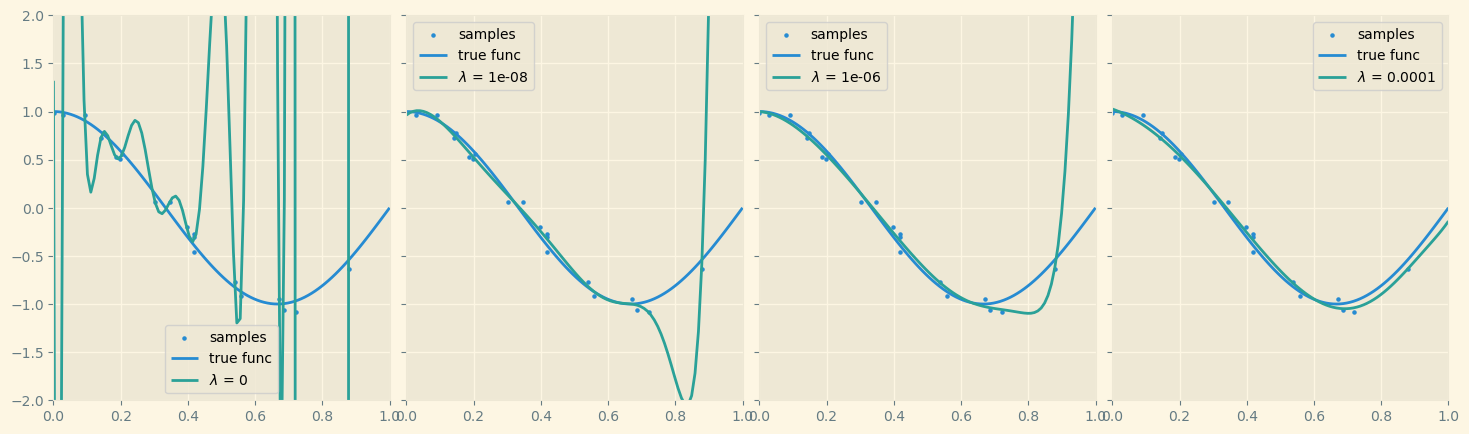

In [36]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures


def true_fun(X):
    return np.cos(1.5 * np.pi * X)


np.random.seed(1)

n_samples = 20
x = np.random.rand(n_samples)
y = true_fun(x) + np.random.randn(n_samples) * 0.1
x_plot = np.linspace(0, 1, 100)

polynomial_features = PolynomialFeatures(degree=20, include_bias=True)
xx_plot = polynomial_features.fit_transform(x_plot[:, np.newaxis])

alpha = [10**i for i in range(-8, -2, 2)]  # 正则项
trial = len(alpha) + 1

with plt.style.context('Solarize_Light2'):
    fig, ax = plt.subplots(1, trial, sharey=True, figsize=(18, 5))
    plt.subplots_adjust(wspace=0.05, hspace=0.05)
    plt.setp(ax, xlim=(0, 1), ylim=(-2, 2))

    for t in range(trial):
        ax[t].scatter(x, y, s=5, label="samples")
        ax[t].plot(x_plot, true_fun(x_plot), label="true func")

        if t == 0:
            lr = LinearRegression()
            label = r'$\lambda$ = 0'
        else:
            lr = Ridge(alpha=alpha[t - 1])
            label = r'$\lambda$ = %s' % (alpha[t - 1])

        xx = polynomial_features.fit_transform(x[:, np.newaxis])
        lr.fit(xx, y)
        ax[t].plot(x_plot, lr.predict(xx_plot), label=label)
        ax[t].legend(loc="best")

    fig.savefig("linear-regression-regularization.svg")
    plt.show()